In [1]:
import numpy as np
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import os
import dill

import config as cfg 
import bdt_lh_cut_opt_with_n_interp as cutopt
plt.style.use('fcc.mplstyle')

import glob
import sys
import ROOT
import math
from tabulate import tabulate
from yaml import safe_load, YAMLError
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from itertools import combinations
 
import efficiency_finder

ROOT.EnableImplicitMT()



Welcome to JupyROOT 6.28/10


In [2]:
data = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe_inclmotherinfo.pkl')

In [3]:
#keep desired branches
flavtag_branches = ["Rec_e","Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "Rec_true_M1", "Rec_true_M2","Rec_true_M1ofM1","Rec_true_M2ofM1","Rec_true_M1ofM2","Rec_true_M2ofM2","decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_e","Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_true_M1", "Rec_true_M2","Rec_true_M1ofM1","Rec_true_M2ofM1","Rec_true_M1ofM2","Rec_true_M2ofM2"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbsfull = data.head(5000)
dfbdfull = data.tail(5000).reset_index(drop=True)

In [4]:
#keep desired branches
def filter_df_on_IDs(dfbsfull,dfbdfull,mask_fn, reco_space_branches= reco_space_branches):
    #mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321)
    filtered_df_dict={}
    key = ['bs','bd']
    for s in range(2):
        df = [dfbsfull,dfbdfull][s]
       
        #create empty dfs to fill
        filtered_df = pd.DataFrame(columns= reco_space_branches )
        
        #loop through events
        for i in range(len(df[reco_space_branches[0]])):
            evt = df.iloc[i]
            mask = mask_fn(evt)
            for var in reco_space_branches:
                filtered_df.loc[i, var] = np.array(evt[var])[mask]
                
        filtered_df_dict[key[s]] = filtered_df
   
    return filtered_df_dict



def filter_df_on_fromPV(dfbsfull, dfbdfull, reco_space_branches= reco_space_branches):
    key = ['bs','bd']
    filtered_df_dict={}
    for s in range(2):
        df = [dfbsfull,dfbdfull][s]
        
        #create empty dfs to fill
        filtered_df=pd.DataFrame(columns= reco_space_branches )
        
        #loop through events
        for i in range(len(df[reco_space_branches[0]])):
            from_PV=[]
            for k in range(len(df['Rec_indvtx'][i])):
                if df['Rec_indvtx'][i][k] == -999:
                    from_PV.append(0)
                else:
                    from_PV.append(np.array(df['Rec_vtx_isPV'][i])[df['Rec_indvtx'][i][k]])
            
            frompv_mask = np.array(from_PV)==1
            
            for var in reco_space_branches:
                filtered_df.loc[i, var] = df.loc[i, var][frompv_mask]
    
        filtered_df_dict[key[s]] = filtered_df
    
    return filtered_df_dict
    

    

In [5]:
def make_maxpK_plots(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    maxp_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
    maxp_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(-1,8))
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(-1,8))
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

     #plot normalised histogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(maxp_bs),1000):
        filter_bs_arr = np.array(maxp_bs) >i
        filter_bd_arr= np.array(maxp_bd) >i
        n_remaining_bs.append(len(np.array(maxp_bs)[filter_bs_arr])/len(maxp_bs))
        n_remaining_bd.append(len(np.array(maxp_bd)[filter_bd_arr])/len(maxp_bd))
        cut_arr.append(i)
    plt.plot(cut_arr,n_remaining_bs,label='Bs') 
    plt.plot(cut_arr,n_remaining_bd,label='Bd') 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on $p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()

def  make_allpK_plot(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    allp_bs =[dfbs['Rec_p'][i][k] for i in range(len(dfbs)) for k in range(len(dfbs['Rec_p'][i]))]
    allp_bd =[dfbd['Rec_p'][i][k] for i in range(len(dfbd)) for k in range(len(dfbd['Rec_p'][i]))]

    #plot hostogram
    plt.hist(allp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(allp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of all'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

def  make_nK_plot(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    num_K_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
    num_K_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(num_K_bs,bins=6, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,6))
    plt.hist(num_K_bd,bins=6, alpha = 0.7, hatch='//',label='Bd',range=(0,6))
    plt.xlabel('Number of'+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

In [6]:
def charged_fsK_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.round(evt['Rec_true_PDG']) == 321) | (np.round(evt['Rec_true_PDG']) == -321)))

def fsK_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321)| (np.array(np.round(evt['Rec_true_PDG'])) == 130)))

def fsKL_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & (np.array(np.round(evt['Rec_true_PDG'])) == 130))

def reco_pi0(evt):
    return (((np.round(evt['Rec_true_PDG']) == 111) | (np.round(evt['Rec_true_PDG']) == -111)))


charged_fsK_dict = filter_df_on_IDs(dfbsfull,dfbdfull,charged_fsK_mask)
fsK_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsK_mask)
fsKL_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsKL_mask)
pi0dict = filter_df_on_IDs(dfbsfull,dfbdfull,reco_pi0)

charged_fsK_dict_fromPV = filter_df_on_IDs(charged_fsK_dict['bs'],charged_fsK_dict['bd'],charged_fsK_mask)
fsK_dict_fromPV = filter_df_on_IDs(fsK_dict['bs'],fsK_dict['bd'],fsK_mask)
fsKL_dict_fromPV = filter_df_on_IDs(fsKL_dict['bs'],fsKL_dict['bd'],fsKL_mask)

In [7]:
indextoremover_bs_pi = pi0dict['bs'][[len(pi0dict['bs']['Rec_p'][i]) == 0 for i in range(len(pi0dict['bs']['Rec_p']))]].index
indextoremover_bd_pi = pi0dict['bd'][[len(pi0dict['bd']['Rec_p'][i]) == 0 for i in range(len(pi0dict['bd']['Rec_p']))]].index
pi0dict['bs'].drop(indextoremover_bs_pi, inplace=True)
pi0dict['bd'].drop(indextoremover_bd_pi, inplace=True)

In [8]:
pi0dict
#ie. no pi0 as final state - all decay to photon photon pair and recorded as such

{'bs': Empty DataFrame
 Columns: [Rec_e, Rec_p, Rec_px, Rec_py, Rec_pz, Rec_pt, Rec_true_PDG, Rec_in_hemisEmin, Rec_indvtx, Rec_true_M1, Rec_true_M2, Rec_true_M1ofM1, Rec_true_M2ofM1, Rec_true_M1ofM2, Rec_true_M2ofM2]
 Index: [],
 'bd': Empty DataFrame
 Columns: [Rec_e, Rec_p, Rec_px, Rec_py, Rec_pz, Rec_pt, Rec_true_PDG, Rec_in_hemisEmin, Rec_indvtx, Rec_true_M1, Rec_true_M2, Rec_true_M1ofM1, Rec_true_M2ofM1, Rec_true_M1ofM2, Rec_true_M2ofM2]
 Index: []}

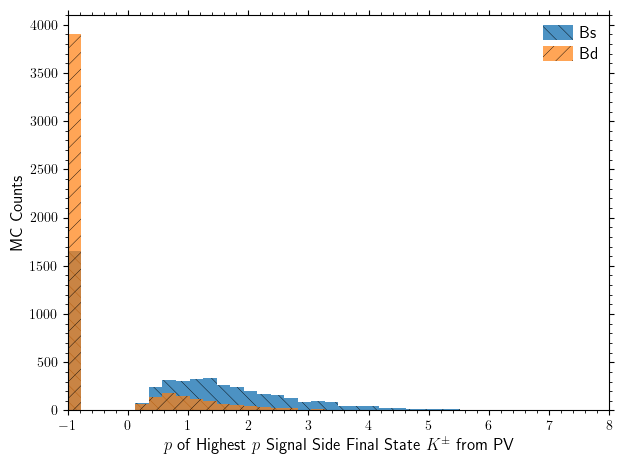

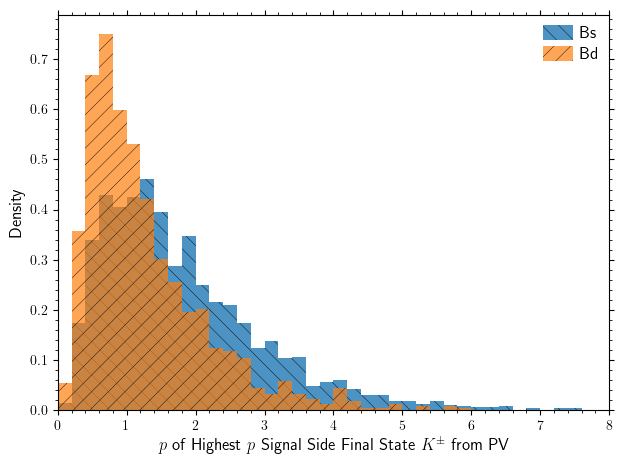

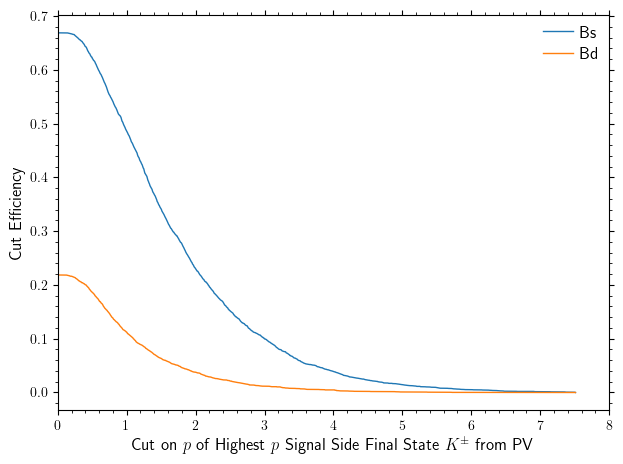

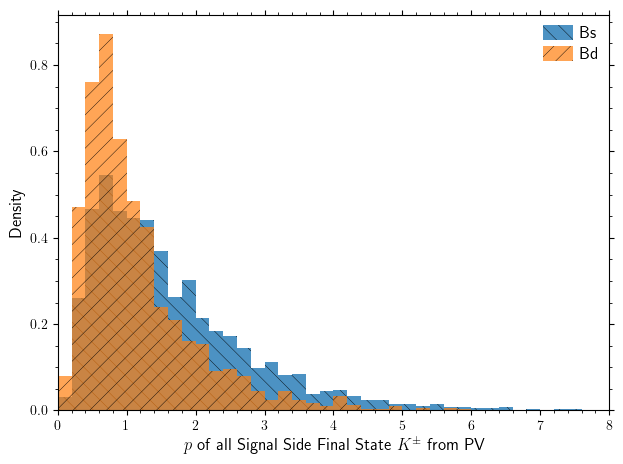

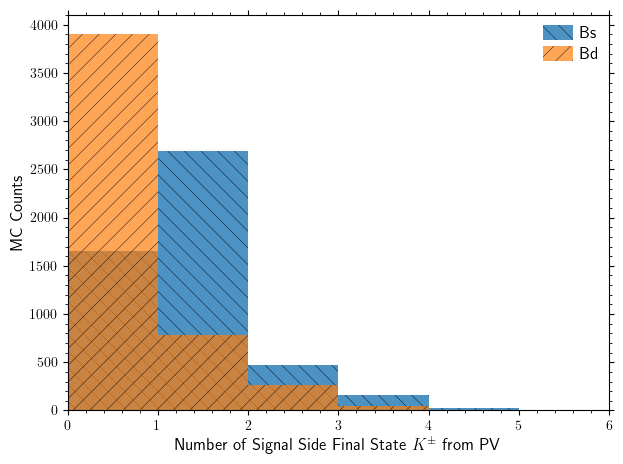

In [9]:
#for charged fsk
make_maxpK_plots(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')
make_allpK_plot(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')
make_nK_plot(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')

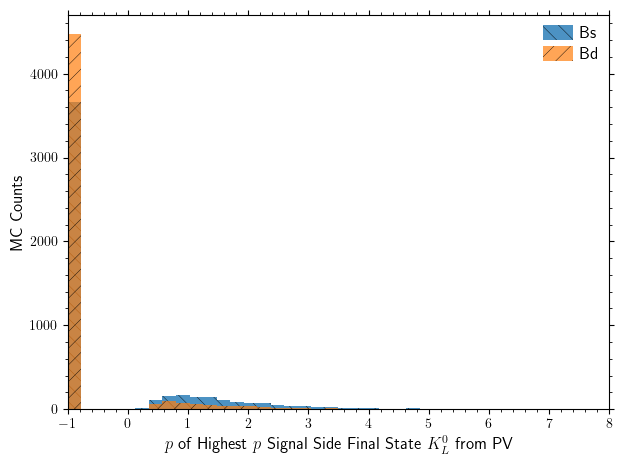

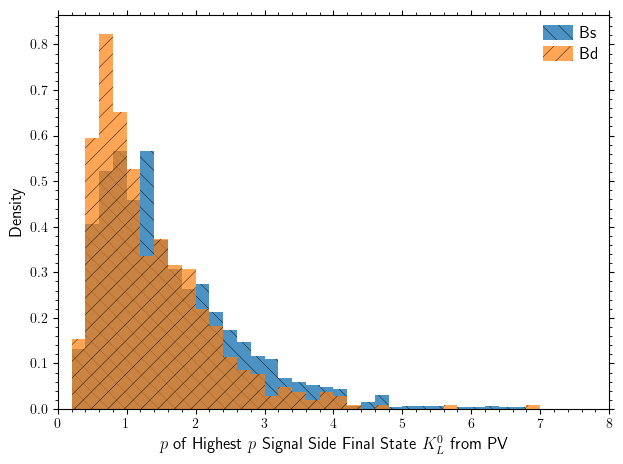

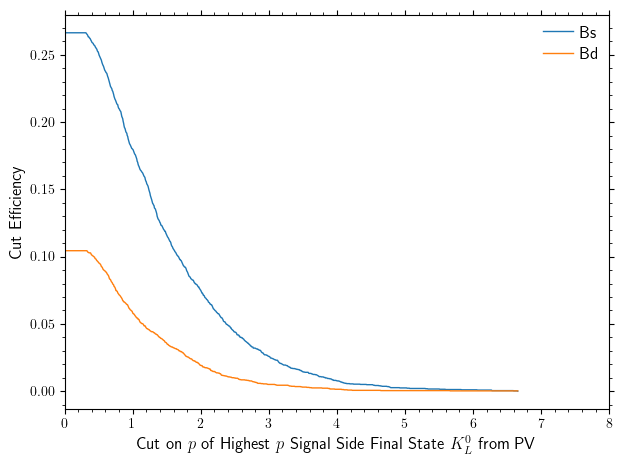

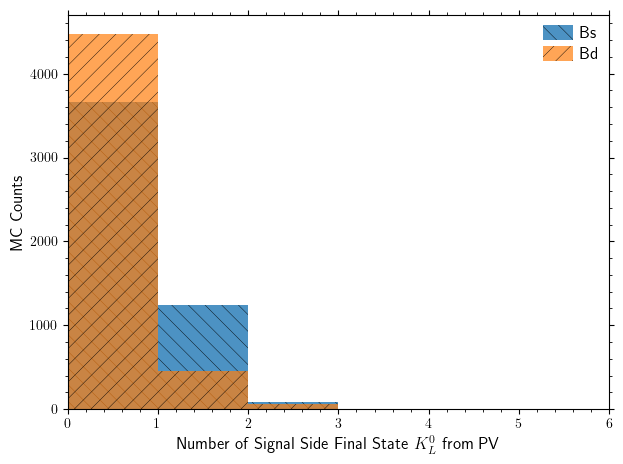

In [10]:
#for Kl
make_maxpK_plots(fsKL_dict_fromPV,K_type = ' Signal Side Final State $K_L^0$ from PV')
make_nK_plot(fsKL_dict_fromPV,K_type = ' Signal Side Final State $K_L^0$ from PV')

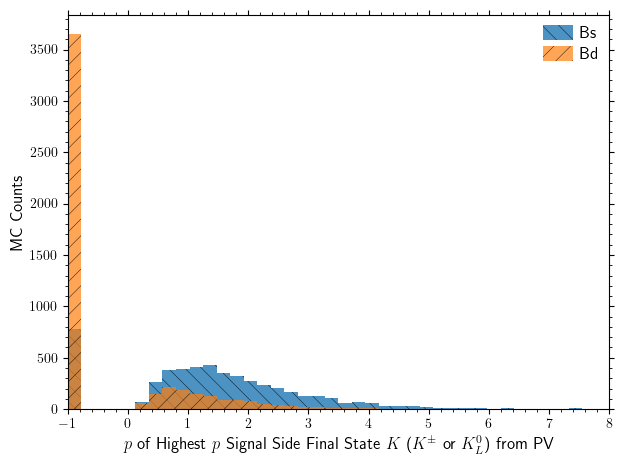

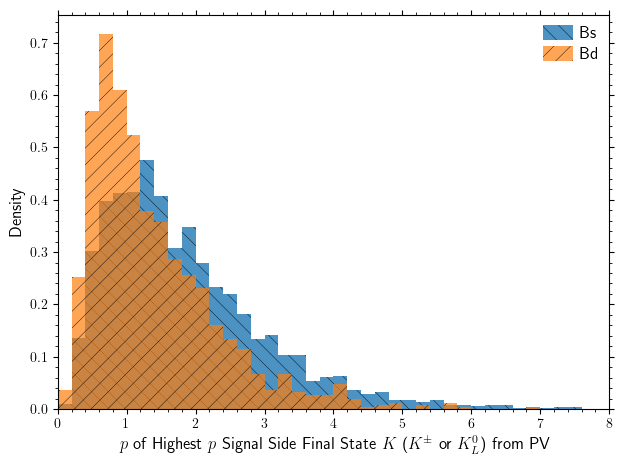

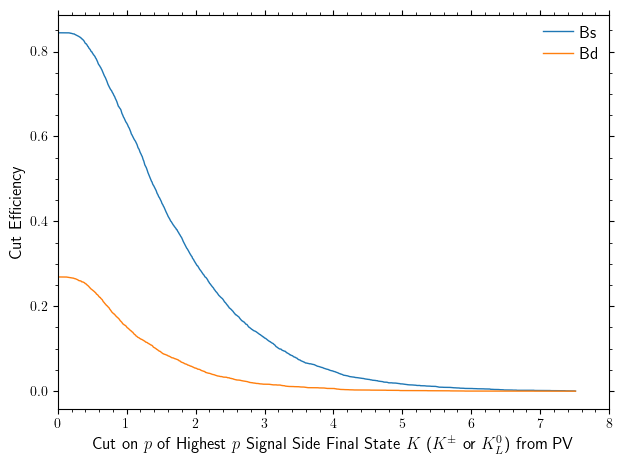

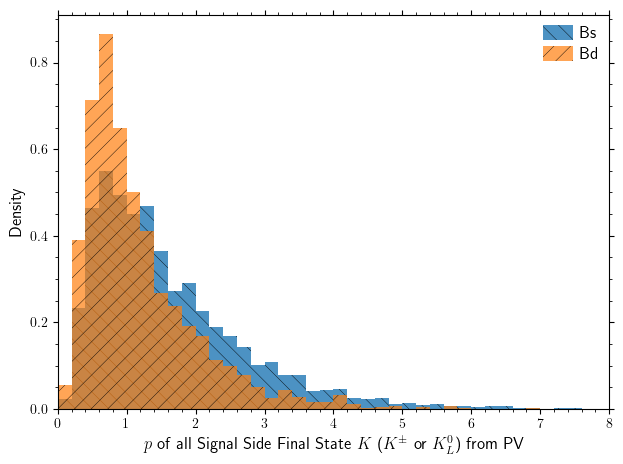

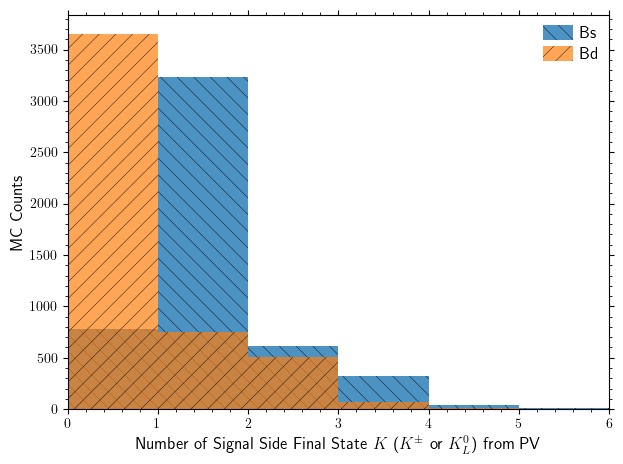

In [11]:
# for all fsK
make_maxpK_plots(fsK_dict_fromPV)
make_allpK_plot(fsK_dict_fromPV)
make_nK_plot(fsK_dict_fromPV)

## K_S

In [12]:
def fsKS_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_M1'])) == 310)|(np.array(np.round(evt['Rec_true_M2'])) == 310)|(np.array(np.round(evt['Rec_true_M1ofM1'])) == 310)|(np.array(np.round(evt['Rec_true_M2ofM1'])) == 310)|(np.array(np.round(evt['Rec_true_M1ofM2'])) == 310)|(np.array(np.round(evt['Rec_true_M2ofM2'])) == 310)))

fsKS_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsKS_mask)

In [13]:
fsKS_dict['bs']

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
0,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
1,[0.8623872995376587],[0.8510181903839111],[0.5674992799758911],[0.4132232666015625],[0.48106449842453003],[0.7020034790039062],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
2,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
3,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
4,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,"[0.5693764686584473, 1.0275379419326782, 0.277...","[0.5693764686584473, 1.0275379419326782, 0.277...","[0.28494709730148315, 0.7856782078742981, 0.19...","[0.40592241287231445, 0.40388739109039307, 0.0...","[0.27968141436576843, 0.524803638458252, 0.191...","[0.49595147371292114, 0.883411169052124, 0.201...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
4996,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
4997,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
4998,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]


In [14]:
# summing momentum of daughters

def  make_sumpK_plot(filtered_dict,K_type = 'Signal Side $K_S^0$ Daughters'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    sum_p_bs =[np.sqrt(sum([dfbs['Rec_px'][i][k] for k in range(len(dfbs['Rec_px'][i]))])**2 + sum([dfbs['Rec_py'][i][k] for k in range(len(dfbs['Rec_py'][i]))])**2+sum([dfbs['Rec_pz'][i][k] for k in range(len(dfbs['Rec_pz'][i]))])**2) for i in range(len(dfbs)) if len(dfbs['Rec_px'][i]) != 0]
    sum_p_bd =[np.sqrt(sum([dfbd['Rec_px'][i][k] for k in range(len(dfbd['Rec_px'][i]))])**2 + sum([dfbd['Rec_py'][i][k] for k in range(len(dfbd['Rec_py'][i]))])**2+sum([dfbd['Rec_pz'][i][k] for k in range(len(dfbd['Rec_pz'][i]))])**2) for i in range(len(dfbd)) if len(dfbd['Rec_px'][i]) != 0]
    
    #plot hostogram
    plt.hist(sum_p_bs,bins=50, alpha = 0.8, hatch='\\\\',label='Bs')
    plt.hist(sum_p_bd,bins=50, alpha = 0.7, hatch='//',label='Bd')
    plt.xlabel('Total $p$ of All '+f'{K_type}'+ ' Per Event')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

    #plot hostogram
    plt.hist(sum_p_bs,bins=50, alpha = 0.8, hatch='\\\\',label='Bs', density=True)
    plt.hist(sum_p_bd,bins=50, alpha = 0.7, hatch='//',label='Bd', density=True)
    plt.xlabel('Total $p$ of All '+f'{K_type}'+ ' Per Event')
    plt.ylabel('Density')
    plt.legend()
    plt.show()


    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(sum_p_bs),1000):
        filter_bs_arr = np.array(sum_p_bs) >i
        filter_bd_arr= np.array(sum_p_bd) >i
        n_remaining_bs.append(len(np.array(sum_p_bs)[filter_bs_arr])/len(fsKS_dict['bs'])) 
        n_remaining_bd.append(len(np.array(sum_p_bd)[filter_bd_arr])/len(fsKS_dict['bd']))
        cut_arr.append(i)
    plt.plot(cut_arr,n_remaining_bs,label='Bs') 
    plt.plot(cut_arr,n_remaining_bd,label='Bd') 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on Total $p$ of All '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()



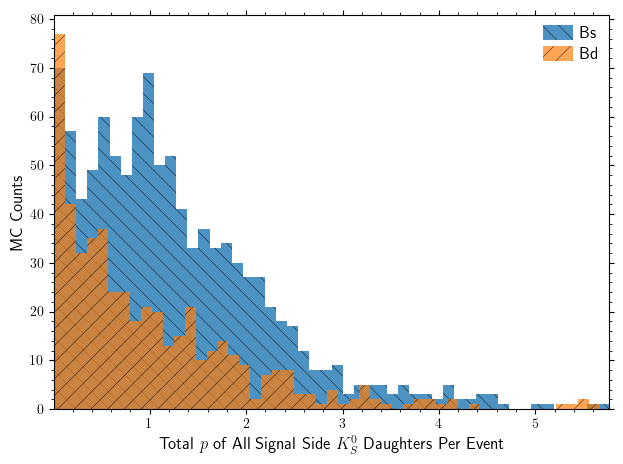

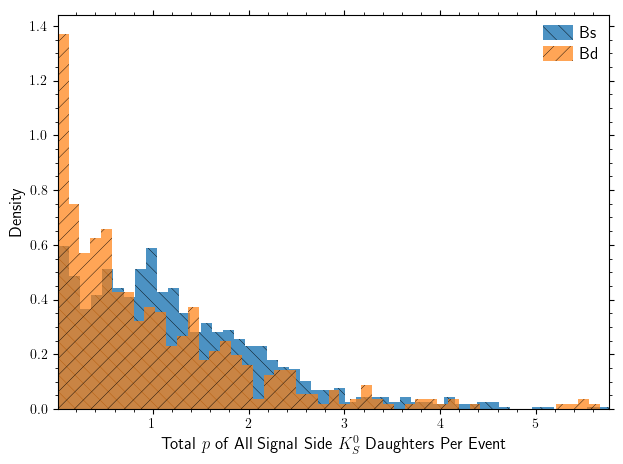

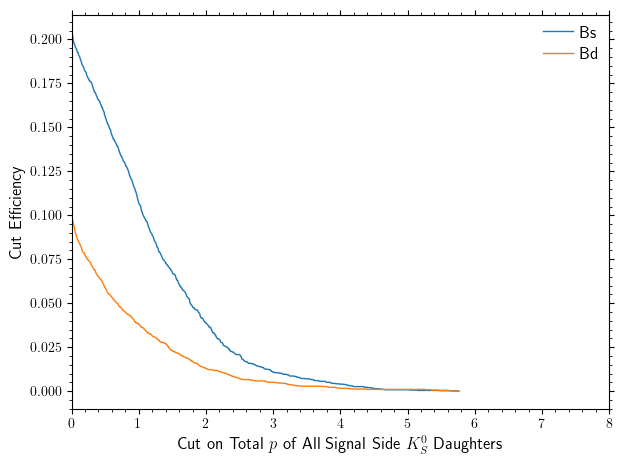

In [15]:
make_sumpK_plot(fsKS_dict)

#### Looking at separating out single and multiple KS events

In [16]:
#remove empty rows for ease of figuring out reco

indextoremover_bs = fsKS_dict['bs'][[len(fsKS_dict['bs']['Rec_p'][i]) == 0 for i in range(len(fsKS_dict['bs']['Rec_p']))]].index
filtered_KS_bs = fsKS_dict['bs'].drop(indextoremover_bs, inplace=False)

indextoremover_bd = fsKS_dict['bd'][[len(fsKS_dict['bd']['Rec_p'][i]) == 0 for i in range(len(fsKS_dict['bd']['Rec_p']))]].index
filtered_KS_bd = fsKS_dict['bd'].drop(indextoremover_bd, inplace=False)

In [17]:
filtered_KS_bd

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
11,[0.9244067072868347],[0.9138095378875732],[0.4640645384788513],[0.3914976418018341],[0.6829506158828735],[0.6071460247039795],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
16,"[0.11950760334730148, 0.14352169632911682]","[0.11950761079788208, 0.14352168142795563]","[0.07545458525419235, -0.107138991355896]","[-0.09267483651638031, -0.031418874859809875]","[-0.00022064575750846416, 0.09018073976039886]","[0.11950740218162537, 0.11165083944797516]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"
32,"[0.33819320797920227, 0.46062323451042175]","[0.30804991722106934, 0.43896910548210144]","[-0.21073146164417267, -0.2677892744541168]","[0.01496627926826477, 0.34486496448516846]","[-0.22419413924217224, 0.045287154614925385]","[0.21126225590705872, 0.43662676215171814]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
45,[0.06929577142000198],[0.06929576396942139],[-0.023248443379998207],[0.050551243126392365],[0.041303571313619614],[0.05564097687602043],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
74,"[0.07067007571458817, 0.3808823823928833, 1.04...","[0.07067006826400757, 0.3808823823928833, 1.04...","[0.015470121055841446, -0.15182310342788696, -...","[-0.024581491947174072, -0.23133806884288788, ...","[-0.06442580372095108, -0.2617323696613312, -0...","[0.02904435247182846, 0.2767084240913391, 0.89...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4957,[0.29548153281211853],[0.2604408860206604],[-0.03911859542131424],[-0.2572454810142517],[0.011133548803627491],[0.2602028250694275],[211.0],[1],[1],[310],[0],[311],[0],[0],[0]
4965,[0.23615224659442902],[0.19049407541751862],[-0.09786660969257355],[0.08659876137971878],[-0.13860292732715607],[0.13067983090877533],[-211.0],[1],[1],[310],[0],[-311],[0],[0],[0]
4970,[0.155398890376091],[0.155398890376091],[-0.05898761376738548],[0.08636993914842606],[-0.11493263393640518],[0.10459113121032715],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
4982,"[0.24429552257061005, 0.640640914440155]","[0.20050039887428284, 0.6252526640892029]","[0.1071464866399765, -0.30956339836120605]","[0.1519317775964737, 0.5411927700042725]","[0.07507847249507904, 0.047135401517152786]","[0.18591298162937164, 0.6234734058380127]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"


In [18]:
filtered_KS_bs

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
1,[0.8623872995376587],[0.8510181903839111],[0.5674992799758911],[0.4132232666015625],[0.48106449842453003],[0.7020034790039062],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
29,"[0.6435591578483582, 0.5672783255577087, 0.593...","[0.6435591578483582, 0.5672783255577087, 0.593...","[-0.15830068290233612, -0.11446399986743927, 0...","[0.32468709349632263, 0.1744694858789444, 0.21...","[0.532623291015625, 0.5275064706802368, 0.5544...","[0.3612212836742401, 0.20866626501083374, 0.21...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985,"[0.5134015679359436, 0.38093382120132446, 0.33...","[0.494066059589386, 0.3544442057609558, 0.3057...","[-0.27134719491004944, 0.20877397060394287, 0....","[0.39378371834754944, 0.22834838926792145, 0.2...","[-0.12412237375974655, 0.17291943728923798, 0....","[0.4782205820083618, 0.3094019293785095, 0.304...","[211.0, -211.0, -211.0]","[1, 1, 1]","[1, -999, 1]","[310, 310, 310]","[0, 0, 0]","[311, 333, 311]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
4989,"[0.059758637100458145, 0.5490507483482361, 2.4...","[0.059758637100458145, 0.5490507483482361, 2.4...","[-0.057876311242580414, -0.5352824330329895, -...","[0.009917674586176872, 0.1194060817360878, 1.0...","[-0.0110935652628541, -0.025915464386343956, -...","[0.05871990695595741, 0.5484387874603271, 2.46...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
4991,"[0.3222982883453369, 0.9096261858940125]","[0.2905103862285614, 0.8988547921180725]","[-0.16681106388568878, -0.775175929069519]","[-0.1448514312505722, -0.45380908250808716]","[-0.18864892423152924, 0.033159129321575165]","[0.22092501819133759, 0.8982429504394531]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4993,"[0.15661723911762238, 0.19338303804397583]","[0.15661723911762238, 0.19338303804397583]","[-0.0011720634065568447, -0.15702567994594574]","[0.05077826976776123, -0.08074475824832916]","[-0.14815247058868408, 0.07886838167905807]","[0.05079179257154465, 0.17656947672367096]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"


In [19]:
# KS to only pi0s
purephoton = []
#loop through events
for i in filtered_KS_bs.index:
    evt = filtered_KS_bs.loc[i]

    if (all(x == 22 for x in evt['Rec_true_PDG']) ==False):
        purephoton.append(i)
KS2purephoton = filtered_KS_bs.drop(purephoton, inplace=False)


nonpi0pi0=[]
#loop through events
for i in KS2purephoton.index:
    evt = KS2purephoton.loc[i]

    if (len(evt['Rec_true_PDG'])%4!=0):
        nonpi0pi0.append(i)

KS2pi0pi0 = KS2purephoton.drop(nonpi0pi0, inplace=False)

In [20]:
KS2pi0pi0

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
29,"[0.6435591578483582, 0.5672783255577087, 0.593...","[0.6435591578483582, 0.5672783255577087, 0.593...","[-0.15830068290233612, -0.11446399986743927, 0...","[0.32468709349632263, 0.1744694858789444, 0.21...","[0.532623291015625, 0.5275064706802368, 0.5544...","[0.3612212836742401, 0.20866626501083374, 0.21...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
49,"[0.15689153969287872, 1.0405622720718384, 1.57...","[0.15689153969287872, 1.0405622720718384, 1.57...","[0.053905148059129715, 0.480439692735672, 0.86...","[0.07558070868253708, 0.5474395751953125, 0.75...","[-0.12647823989391327, -0.7431403398513794, -1...","[0.09283430874347687, 0.7283627986907959, 1.14...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
59,"[1.8461087942123413, 1.472984790802002, 0.0460...","[1.8461089134216309, 1.472984790802002, 0.0460...","[-0.8537778258323669, -0.3565816581249237, -0....","[-1.054087519645691, -0.9144601821899414, -0.0...","[1.2522304058074951, 1.0983152389526367, 0.034...","[1.3564796447753906, 0.9815232753753662, 0.030...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
86,"[0.3765491247177124, 1.6385612487792969, 0.981...","[0.3765491545200348, 1.6385612487792969, 0.981...","[0.15497878193855286, 0.600326418876648, 0.587...","[0.19168394804000854, 0.9731080532073975, 0.46...","[-0.2846543788909912, -1.1736916303634644, -0....","[0.24649779498577118, 1.1433857679367065, 0.74...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
104,"[0.3037242293357849, 0.14944572746753693, 0.27...","[0.3037242591381073, 0.14944572746753693, 0.27...","[-0.028232187032699585, 0.05269940569996834, 0...","[0.3017272353172302, 0.1294897198677063, 0.121...","[-0.02029869332909584, 0.052812978625297546, 0...","[0.3030451834201813, 0.13980276882648468, 0.24...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4910,"[0.09113553166389465, 0.4757233262062073, 0.31...","[0.09113553166389465, 0.4757233262062073, 0.31...","[0.01793956384062767, 0.45318254828453064, 0.2...","[0.02490140311419964, -0.03347466140985489, 0....","[-0.08581245690584183, -0.1407754272222519, -0...","[0.030690517276525497, 0.4544171690940857, 0.3...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
4933,"[1.0280815362930298, 0.4927440881729126, 1.017...","[1.0280815362930298, 0.4927440881729126, 1.017...","[-0.09047217667102814, 0.02187310717999935, -0...","[0.9590007662773132, 0.43876227736473083, 0.82...","[0.35928264260292053, 0.22317251563072205, 0.5...","[0.9632588624954224, 0.43930715322494507, 0.84...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
4952,"[0.994836151599884, 0.32969868183135986, 0.182...","[0.994836151599884, 0.3296986520290375, 0.1827...","[0.15213485062122345, -0.00901090819388628, 0....","[0.359356552362442, 0.16196899116039276, 0.076...","[-0.9151048064231873, -0.2870297133922577, -0....","[0.39023345708847046, 0.16221944987773895, 0.1...","[22.0, 22.0, 

In [21]:
# KS to only pi0s
purepion = []
#loop through events
for i in filtered_KS_bs.index:
    evt = filtered_KS_bs.loc[i]

    if (all((x == 211) |(x == -211) for x in evt['Rec_true_PDG'])) ==False:
        purepion.append(i)
        
KS2purepion = filtered_KS_bs.drop(purepion, inplace=False)


nonoverallneutral=[]
#loop through events
for i in KS2purepion.index:
    evt = KS2purepion.loc[i]

    if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==211]) != len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==-211])):
        nonoverallneutral.append(i)

KS2pippim = KS2purepion.drop(nonoverallneutral, inplace=False)


In [22]:
KS2purepion

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
1,[0.8623872995376587],[0.8510181903839111],[0.5674992799758911],[0.4132232666015625],[0.48106449842453003],[0.7020034790039062],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
89,"[0.43672022223472595, 0.9537316560745239]","[0.4138171970844269, 0.943463921546936]","[0.35695701837539673, 0.5169071555137634]","[0.010534791275858879, -0.4710950255393982]","[-0.2090822160243988, -0.633246123790741]","[0.35711243748664856, 0.6993736624717712]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4965,"[1.7524704933166504, 0.22886325418949127]","[1.7469037771224976, 0.18137942254543304]","[0.8651428818702698, 0.13347549736499786]","[-1.289629578590393, -0.08531525731086731]","[0.8000351786613464, 0.08834077417850494]","[1.5529381036758423, 0.1584121286869049]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4969,"[1.7328733205795288, 0.21276035904884338]","[1.7272435426712036, 0.16058354079723358]","[1.5316152572631836, 0.1347702592611313]","[0.706803560256958, 0.04152693971991539]","[0.37142112851142883, 0.0768086314201355]","[1.6868362426757812, 0.14102308452129364]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4981,"[0.2806720435619354, 0.4391253888607025]","[0.24350956082344055, 0.4163546562194824]","[0.13081076741218567, -0.30539238452911377]","[0.06257138401269913, 0.1449810117483139]","[0.19562788307666779, 0.24303744733333588]","[0.14500562846660614, 0.3380591571331024]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
4985,"[0.5134015679359436, 0.38093382120132446, 0.33...","[0.494066059589386, 0.3544442057609558, 0.3057...","[-0.27134719491004944, 0.20877397060394287, 0....","[0.39378371834754944, 0.22834838926792145, 0.2...","[-0.12412237375974655, 0.17291943728923798, 0....","[0.4782205820083618, 0.3094019293785095, 0.304...","[211.0, -211.0, -211.0]","[1, 1, 1]","[1, -999, 1]","[310, 310, 310]","[0, 0, 0]","[311, 333, 311]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"


In [23]:
KS2pippim

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
89,"[0.43672022223472595, 0.9537316560745239]","[0.4138171970844269, 0.943463921546936]","[0.35695701837539673, 0.5169071555137634]","[0.010534791275858879, -0.4710950255393982]","[-0.2090822160243988, -0.633246123790741]","[0.35711243748664856, 0.6993736624717712]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
99,"[0.5915308594703674, 0.5543510317802429]","[0.5748293995857239, 0.5364933609962463]","[0.013178684748709202, -0.35768410563468933]","[-0.3484724760055542, -0.20656898617744446]","[0.45697054266929626, 0.3423689305782318]","[0.34872159361839294, 0.41304799914360046]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4927,"[0.36762139201164246, 2.631624221801758]","[0.34009644389152527, 2.627920389175415]","[0.20941652357578278, 1.976060152053833]","[0.1556207835674286, 1.2838308811187744]","[-0.21815700829029083, -1.1631553173065186]","[0.26090824604034424, 2.356487989425659]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
4965,"[1.7524704933166504, 0.22886325418949127]","[1.7469037771224976, 0.18137942254543304]","[0.8651428818702698, 0.13347549736499786]","[-1.289629578590393, -0.08531525731086731]","[0.8000351786613464, 0.08834077417850494]","[1.5529381036758423, 0.1584121286869049]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4969,"[1.7328733205795288, 0.21276035904884338]","[1.7272435426712036, 0.16058354079723358]","[1.5316152572631836, 0.1347702592611313]","[0.706803560256958, 0.04152693971991539]","[0.37142112851142883, 0.0768086314201355]","[1.6868362426757812, 0.14102308452129364]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4981,"[0.2806720435619354, 0.4391253888607025]","[0.24350956082344055, 0.4163546562194824]","[0.13081076741218567, -0.30539238452911377]","[0.06257138401269913, 0.1449810117483139]","[0.19562788307666779, 0.24303744733333588]","[0.14500562846660614, 0.3380591571331024]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"


In [24]:
pi0pi0_pippim_indices = np.concatenate((np.array(KS2pi0pi0.index),np.array(KS2pippim.index)))

In [25]:
non_pi0pi0_pippim_indices = list(set(filtered_KS_bs.index) - set(pi0pi0_pippim_indices))

filtered_KS_bs.loc[non_pi0pi0_pippim_indices].sort_index()

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
1,[0.8623872995376587],[0.8510181903839111],[0.5674992799758911],[0.4132232666015625],[0.48106449842453003],[0.7020034790039062],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
52,"[0.51975017786026, 0.07518443465232849, 0.1635...","[0.51975017786026, 0.07518443465232849, 0.1635...","[0.07870856672525406, -0.031075041741132736, -...","[-0.3656679093837738, -0.0575689822435379, -0....","[-0.3608769476413727, -0.03705203905701637, -0...","[0.3740428686141968, 0.06542053073644638, 0.14...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
61,"[0.10638309270143509, 0.2770051658153534]","[0.10638309270143509, 0.2770051658153534]","[-0.10145679116249084, 0.14768627285957336]","[-0.01394381932914257, -0.11379346251487732]","[-0.028800206258893013, 0.20486989617347717]","[0.10241050273180008, 0.1864408403635025]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"
65,"[0.09529922902584076, 0.0727730542421341, 0.06...","[0.09529922902584076, 0.07277306169271469, 0.0...","[-0.0587308406829834, 0.07170522212982178, 0.0...","[-0.07242856919765472, -0.010114235803484917, ...","[-0.019665541127324104, 0.007209813687950373, ...","[0.09324810653924942, 0.07241503149271011, 0.0...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
66,"[0.35850760340690613, 0.05442937836050987, 0.1...","[0.35850757360458374, 0.05442937836050987, 0.1...","[-0.01831103302538395, 0.004322524648159742, 0...","[-0.315789133310318, -0.042647939175367355, -0...","[0.16872942447662354, 0.03354141116142273, 0.1...","[0.3163195848464966, 0.042866431176662445, 0.1...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4951,[0.47306081652641296],[0.47306081652641296],[-0.3191765248775482],[-0.147637739777565],[0.3164111077785492],[0.35166823863983154],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
4980,[0.010068930685520172],[0.010068930685520172],[-0.0023976746015250683],[-0.009173200465738773],[0.0033892339561134577],[0.00948137417435646],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
4985,"[0.5134015679359436, 0.38093382120132446, 0.33...","[0.494066059589386, 0.3544442057609558, 0.3057...","[-0.27134719491004944, 0.20877397060394287, 0....","[0.39378371834754944, 0.22834838926792145, 0.2...","[-0.12412237375974655, 0.17291943728923798, 0....","[0.4782205820083618, 0.3094019293785095, 0.304...","[211.0, -211.0, -211.0]","[1, 1, 1]","[1, -999, 1]","[310, 310, 310]","[0, 0, 0]","[311, 333, 311]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
4993,"[0.15661723911762238, 0.19338303804397583]","[0.15661723911762238, 0.19338303804397583]","[-0.0011720634065568447, -0.15702567994594574]","[0.05077826976776123, -0.08074475824832916]","[-0.14815247058868408, 0.07886838167905807]","[0.05079179257154465, 0.17656947672367096]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"


In [26]:
part_reco=[]
#loop through events
for i in filtered_KS_bs.index:
    evt = filtered_KS_bs.loc[i]

    if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==211]) != len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==-211])):
        part_reco.append(i)
    elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])%4!=0):
        part_reco.append(i)

KSreconstructed = filtered_KS_bs.drop(part_reco, inplace=False)


In [27]:
print(len(filtered_KS_bs))
KSreconstructed

1019


,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
29,"[0.6435591578483582, 0.5672783255577087, 0.593...","[0.6435591578483582, 0.5672783255577087, 0.593...","[-0.15830068290233612, -0.11446399986743927, 0...","[0.32468709349632263, 0.1744694858789444, 0.21...","[0.532623291015625, 0.5275064706802368, 0.5544...","[0.3612212836742401, 0.20866626501083374, 0.21...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
49,"[0.15689153969287872, 1.0405622720718384, 1.57...","[0.15689153969287872, 1.0405622720718384, 1.57...","[0.053905148059129715, 0.480439692735672, 0.86...","[0.07558070868253708, 0.5474395751953125, 0.75...","[-0.12647823989391327, -0.7431403398513794, -1...","[0.09283430874347687, 0.7283627986907959, 1.14...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4967,"[0.13125832378864288, 0.1324024200439453, 1.29...","[0.1312583088874817, 0.1324024200439453, 1.294...","[0.04490240663290024, 0.01300506666302681, 0.8...","[-0.02775469236075878, -0.06740856915712357, -...","[-0.12017568945884705, -0.11321374773979187, -...","[0.05278777331113815, 0.06865163892507553, 0.8...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
4969,"[1.7328733205795288, 0.21276035904884338]","[1.7272435426712036, 0.16058354079723358]","[1.5316152572631836, 0.1347702592611313]","[0.706803560256958, 0.04152693971991539]","[0.37142112851142883, 0.0768086314201355]","[1.6868362426757812, 0.14102308452129364]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4981,"[0.2806720435619354, 0.4391253888607025]","[0.24350956082344055, 0.4163546562194824]","[0.13081076741218567, -0.30539238452911377]","[0.06257138401269913, 0.1449810117483139]","[0.19562788307666779, 0.24303744733333588]","[0.14500562846660614, 0.3380591571331024]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
4989,"[0.059758637100458145, 0.5490507483482361, 2.4...","[0.059758637100458145, 0.5490507483482361, 2.4...","[-0.057876311242580414, -0.5352824330329895, -...","[0.009917674586176872, 0.1194060817360878, 1.0...","[-0.0110935652628541, -0.025915464386343956, -...","[0.05871990695595741, 0.5484387874603271, 2.46...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0

In [28]:
KS_req4vect=[]
#loop through events
for i in KSreconstructed.index:
    evt = KSreconstructed.loc[i]

    if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])>2):
        KS_req4vect.append(i)
    elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])>4):
        KS_req4vect.append(i)

KSreconstructed_simplepsum = KSreconstructed.drop(KS_req4vect, inplace=False)
KSreconstructed_req4vect =KSreconstructed.loc[KS_req4vect].sort_index()



In [29]:
KSreconstructed_simplepsum

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
29,"[0.6435591578483582, 0.5672783255577087, 0.593...","[0.6435591578483582, 0.5672783255577087, 0.593...","[-0.15830068290233612, -0.11446399986743927, 0...","[0.32468709349632263, 0.1744694858789444, 0.21...","[0.532623291015625, 0.5275064706802368, 0.5544...","[0.3612212836742401, 0.20866626501083374, 0.21...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
49,"[0.15689153969287872, 1.0405622720718384, 1.57...","[0.15689153969287872, 1.0405622720718384, 1.57...","[0.053905148059129715, 0.480439692735672, 0.86...","[0.07558070868253708, 0.5474395751953125, 0.75...","[-0.12647823989391327, -0.7431403398513794, -1...","[0.09283430874347687, 0.7283627986907959, 1.14...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4967,"[0.13125832378864288, 0.1324024200439453, 1.29...","[0.1312583088874817, 0.1324024200439453, 1.294...","[0.04490240663290024, 0.01300506666302681, 0.8...","[-0.02775469236075878, -0.06740856915712357, -...","[-0.12017568945884705, -0.11321374773979187, -...","[0.05278777331113815, 0.06865163892507553, 0.8...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
4969,"[1.7328733205795288, 0.21276035904884338]","[1.7272435426712036, 0.16058354079723358]","[1.5316152572631836, 0.1347702592611313]","[0.706803560256958, 0.04152693971991539]","[0.37142112851142883, 0.0768086314201355]","[1.6868362426757812, 0.14102308452129364]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]"
4981,"[0.2806720435619354, 0.4391253888607025]","[0.24350956082344055, 0.4163546562194824]","[0.13081076741218567, -0.30539238452911377]","[0.06257138401269913, 0.1449810117483139]","[0.19562788307666779, 0.24303744733333588]","[0.14500562846660614, 0.3380591571331024]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
4989,"[0.059758637100458145, 0.5490507483482361, 2.4...","[0.059758637100458145, 0.5490507483482361, 2.4...","[-0.057876311242580414, -0.5352824330329895, -...","[0.009917674586176872, 0.1194060817360878, 1.0...","[-0.0110935652628541, -0.025915464386343956, -...","[0.05871990695595741, 0.5484387874603271, 2.46...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0

In [30]:
evt['Rec_px'][evt['Rec_true_PDG']==22]

array([], dtype=float64)

In [31]:
#loop through events
KSreconstructed_simplepsum['KS_p'] =pd.Series(
    [np.array([]) for _ in range(len(KSreconstructed_simplepsum))],
    index=KSreconstructed_simplepsum.index,dtype=object)

for i in KSreconstructed_simplepsum.index:
   
    evt = KSreconstructed_simplepsum.loc[i]
    KS_p = []

    if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])>0):
        px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
        KS_p.append(p)
        
    
    if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])>0):
        px = evt['Rec_px'][evt['Rec_true_PDG']==22]
        py = evt['Rec_py'][evt['Rec_true_PDG']==22]
        pz = evt['Rec_pz'][evt['Rec_true_PDG']==22]
        p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
        KS_p.append(p)

    if len(KS_p)>1:
        print(KS_p)

    KSreconstructed_simplepsum.at[i, 'KS_p']= np.array(KS_p) #nb. order of KS will be one with charged daughters before one with neutral if >1 but this somewhat arbitrary


[0.6460101007780878, 0.5380797105216368]
[1.3567578447827535, 0.9414617286251866]
[0.7355979031626161, 1.5545328700606271]
[1.1263253237061333, 1.1348107874099216]
[2.3392294629117383, 1.578812086095553]
[1.2387300603292253, 1.0249161989982059]
[1.317145023006815, 1.783494081276026]
[1.1139541757195344, 0.8298900121273055]


In [32]:
filtered_KS_bd

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
11,[0.9244067072868347],[0.9138095378875732],[0.4640645384788513],[0.3914976418018341],[0.6829506158828735],[0.6071460247039795],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
16,"[0.11950760334730148, 0.14352169632911682]","[0.11950761079788208, 0.14352168142795563]","[0.07545458525419235, -0.107138991355896]","[-0.09267483651638031, -0.031418874859809875]","[-0.00022064575750846416, 0.09018073976039886]","[0.11950740218162537, 0.11165083944797516]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"
32,"[0.33819320797920227, 0.46062323451042175]","[0.30804991722106934, 0.43896910548210144]","[-0.21073146164417267, -0.2677892744541168]","[0.01496627926826477, 0.34486496448516846]","[-0.22419413924217224, 0.045287154614925385]","[0.21126225590705872, 0.43662676215171814]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"
45,[0.06929577142000198],[0.06929576396942139],[-0.023248443379998207],[0.050551243126392365],[0.041303571313619614],[0.05564097687602043],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
74,"[0.07067007571458817, 0.3808823823928833, 1.04...","[0.07067006826400757, 0.3808823823928833, 1.04...","[0.015470121055841446, -0.15182310342788696, -...","[-0.024581491947174072, -0.23133806884288788, ...","[-0.06442580372095108, -0.2617323696613312, -0...","[0.02904435247182846, 0.2767084240913391, 0.89...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4957,[0.29548153281211853],[0.2604408860206604],[-0.03911859542131424],[-0.2572454810142517],[0.011133548803627491],[0.2602028250694275],[211.0],[1],[1],[310],[0],[311],[0],[0],[0]
4965,[0.23615224659442902],[0.19049407541751862],[-0.09786660969257355],[0.08659876137971878],[-0.13860292732715607],[0.13067983090877533],[-211.0],[1],[1],[310],[0],[-311],[0],[0],[0]
4970,[0.155398890376091],[0.155398890376091],[-0.05898761376738548],[0.08636993914842606],[-0.11493263393640518],[0.10459113121032715],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
4982,"[0.24429552257061005, 0.640640914440155]","[0.20050039887428284, 0.6252526640892029]","[0.1071464866399765, -0.30956339836120605]","[0.1519317775964737, 0.5411927700042725]","[0.07507847249507904, 0.047135401517152786]","[0.18591298162937164, 0.6234734058380127]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]"


In [33]:
#repeat in full for Bd
part_reco=[]
#loop through events
for i in filtered_KS_bd.index:
    evt = filtered_KS_bd.loc[i]

    if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==211]) != len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==-211])):
        part_reco.append(i)
    elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])%4!=0):
        part_reco.append(i)

KSreconstructed_bd = filtered_KS_bd.drop(part_reco, inplace=False)

KS_req4vect=[]
#loop through events
for i in KSreconstructed_bd.index:
    evt = KSreconstructed_bd.loc[i]

    if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])>2):
        KS_req4vect.append(i)
    elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])>4):
        KS_req4vect.append(i)

KSreconstructed_bd_simplepsum = KSreconstructed_bd.drop(KS_req4vect, inplace=False)
KSreconstructed_bd_req4vect =KSreconstructed_bd.loc[KS_req4vect].sort_index()

#loop through events
KSreconstructed_bd_simplepsum['KS_p'] = pd.Series(
    [np.array([]) for _ in range(len(KSreconstructed_bd_simplepsum))],
    index=KSreconstructed_bd_simplepsum.index,dtype=object)

for i in KSreconstructed_bd_simplepsum.index:
   
    evt = KSreconstructed_bd_simplepsum.loc[i]
    KS_p = []

    if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])>0):
        px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
        KS_p.append(p)
        
    
    if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])>0):
        px = evt['Rec_px'][evt['Rec_true_PDG']==22]
        py = evt['Rec_py'][evt['Rec_true_PDG']==22]
        pz = evt['Rec_pz'][evt['Rec_true_PDG']==22]
        p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
        KS_p.append(p)

    if len(KS_p)>1:
        print(KS_p)

    KSreconstructed_bd_simplepsum.at[i, 'KS_p']= np.array(KS_p) #nb. order of KS will be one with charged daughters before one with neutral if >1 but this somewhat arbitrary


[2.012142127835181, 2.3400042624930832]
[1.160407182959754, 0.6879543354047142]
[1.6736042454118671, 0.6657459360890196]
[3.022962063629053, 0.7949662751636744]
[0.9575604852435264, 0.8320750528975196]
[0.3234187087564848, 3.541199362997623]
[1.6966107065907408, 1.5389861613112783]
[2.3498461650043345, 1.466218882388471]


[0.9135056554313756, 1.0618877245026275]
[1.8515519475589421, 2.140961484407383]


In [34]:
fsKS_dict['bs']['KS_p'] = pd.Series(
    [np.array([]) for _ in range(len(fsKS_dict['bs']))],
    index=fsKS_dict['bs'].index,dtype=object)

for i in KSreconstructed_simplepsum.index:
    fsKS_dict['bs'].at[i, 'KS_p'] = KSreconstructed_simplepsum['KS_p'][i]

fsKS_dict['bd']['KS_p'] = pd.Series(
    [np.array([]) for _ in range(len(fsKS_dict['bd']))],
    index=fsKS_dict['bd'].index,dtype=object)#pd.Series([None])

for i in KSreconstructed_bd_simplepsum.index:
    fsKS_dict['bd'].at[i, 'KS_p'] = KSreconstructed_bd_simplepsum['KS_p'][i]


In [35]:
def make_maxpKS_plots(filtered_dict,K_type = ' Signal Side $K_s^0$'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    maxp_bs =[np.max(dfbs['KS_p'][i]) if len(dfbs['KS_p'][i]) != 0 else -1 for i in range(len(dfbs))]
    maxp_bd =[np.max(dfbd['KS_p'][i]) if len(dfbd['KS_p'][i]) != 0 else -1 for i in range(len(dfbd))]


    #plot hostogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(-1,8))
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(-1,8))
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

     #plot normalised histogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(maxp_bs),1000):
        filter_bs_arr = np.array(maxp_bs) >i
        filter_bd_arr= np.array(maxp_bd) >i
        n_remaining_bs.append(len(np.array(maxp_bs)[filter_bs_arr])/len(maxp_bs))
        n_remaining_bd.append(len(np.array(maxp_bd)[filter_bd_arr])/len(maxp_bd))
        cut_arr.append(i)
    plt.plot(cut_arr,n_remaining_bs,label='Bs') 
    plt.plot(cut_arr,n_remaining_bd,label='Bd') 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on $p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()

def  make_allpKS_plot(filtered_dict,K_type = ' Signal Side $K_s^0$'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    allp_bs =[dfbs['KS_p'][i][k] for i in range(len(dfbs)) for k in range(len(dfbs['KS_p'][i]))]
    allp_bd =[dfbd['KS_p'][i][k] for i in range(len(dfbd)) for k in range(len(dfbd['KS_p'][i]))]

    #plot hostogram
    plt.hist(allp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(allp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of all'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

def  make_nKS_plot(filtered_dict,K_type = ' Signal Side $K_s^0$'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    num_K_bs =[len(dfbs['KS_p'][i]) for i in range(len(dfbs))]
    num_K_bd =[len(dfbd['KS_p'][i]) for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(num_K_bs,bins=6, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,6))
    plt.hist(num_K_bd,bins=6, alpha = 0.7, hatch='//',label='Bd',range=(0,6))
    plt.xlabel('Number of'+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

In [36]:
type(fsKS_dict['bd']['KS_p'][1])

numpy.ndarray

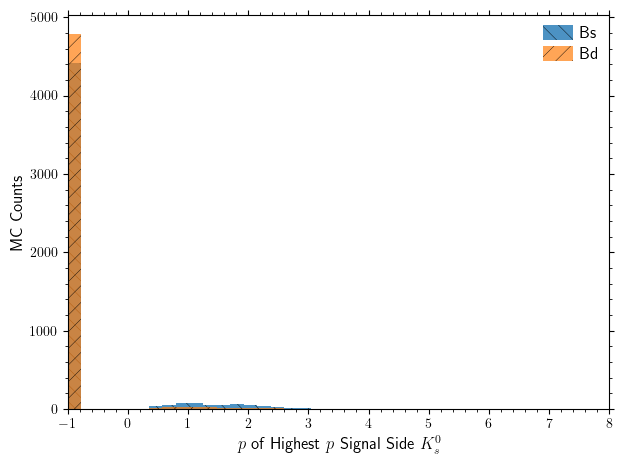

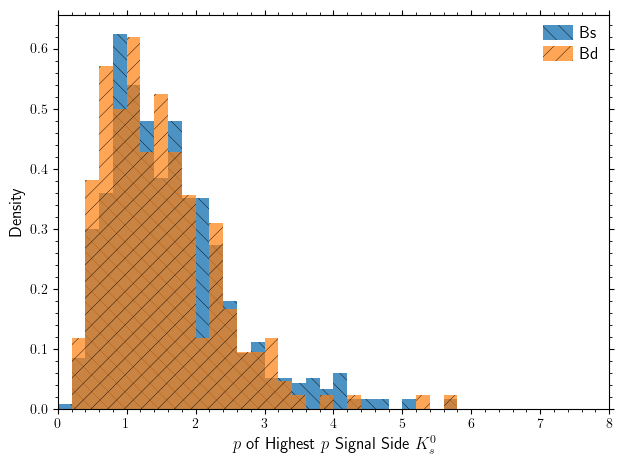

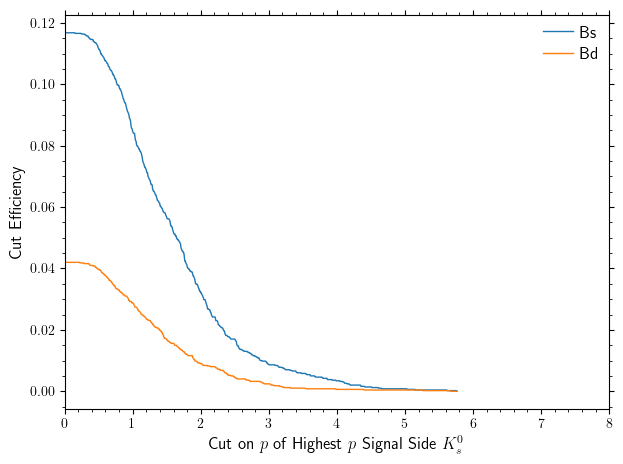

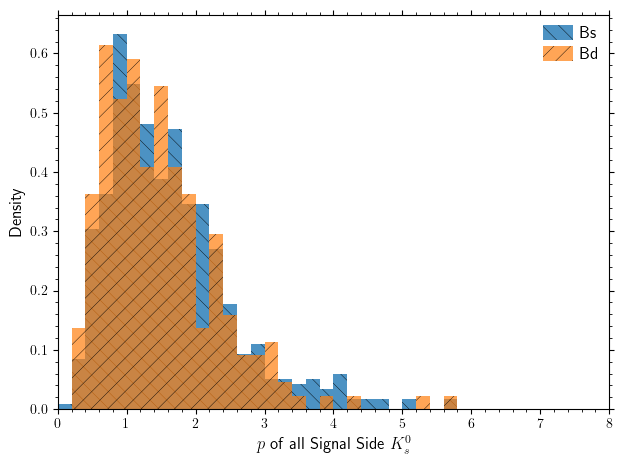

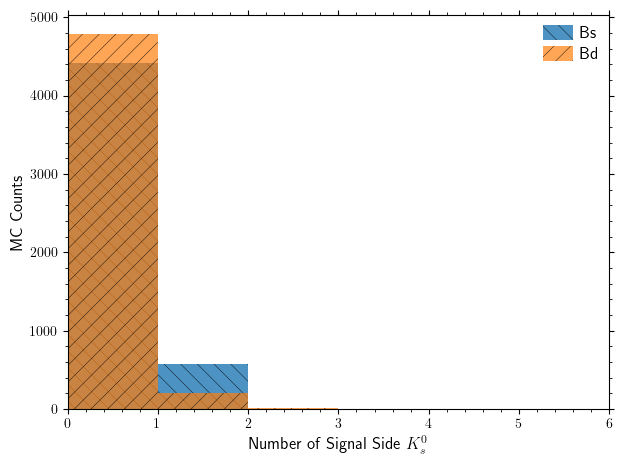

In [37]:
make_maxpKS_plots(fsKS_dict)
make_allpKS_plot(fsKS_dict)
make_nKS_plot(fsKS_dict)


In [69]:
KS_PDG_m = cfg.mass_KS
pi0_PDG_m = cfg.mass_pi0

#create KS_p colum
KSreconstructed_req4vect['KS_p'] = pd.Series(
    [np.array([]) for _ in range(len(KSreconstructed_req4vect))],
    index=KSreconstructed_req4vect.index,dtype=object)

for i in KSreconstructed_req4vect.index:
    evt = KSreconstructed_req4vect.loc[i]
    KS_p=[]


    if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))==2:
        px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
        KS_p.append(p)
        
        
    elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))>2:
        E = evt['Rec_e'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
        pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]

        
        n = len(E)
        indices = list(range(len(E)))

        # Step 1: Generate all index pairs (i < j)
        all_pairs = list(combinations(indices, 2))

        # Step 2: Filter for combinations of pairs that:
        # - cover all indices
        # - do not share any index (i.e., disjoint pairs)
        def is_disjoint(pairing):
            used = set()
            for i, j in pairing:
                if i in used or j in used:
                    return False
                used.update([i, j])
            return True

        # Step 3: Generate all combinations of n//2 pairs
        valid_pairings = []
        for combo in combinations(all_pairs, n // 2):
            if is_disjoint(combo):
                valid_pairings.append(combo)



        # Step 4: Compute the sum of each valid pairing set
        results = []
        for pairing in valid_pairings:

            total_E = np.array([E[i] + E[j] for i, j in pairing])
            total_px =  np.array([px[i] + px[j] for i, j in pairing])
            total_py =  np.array([py[i] + py[j] for i, j in pairing])
            total_pz =  np.array([pz[i] + pz[j] for i, j in pairing])

            abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - KS_PDG_m))
            results.append((pairing, abs_total_inv_mass_diff_sum))

        min_pairing, min_total = min(results, key=lambda x: x[1])
        #print(f"\nCorrect Pairing: {min_pairing}, Total abs deviation from KS mass: {min_total}")

        KS_px =  np.array([px[i] + px[j] for i, j in min_pairing])
        KS_py =  np.array([py[i] + py[j] for i, j in min_pairing])
        KS_pz =  np.array([pz[i] + pz[j] for i, j in min_pairing])

        p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)
        KS_p.extend(p)

    else:
        print(f"Number of charged pions= {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])}")
         

    if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))==4:
        px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
        py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
        pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
        p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
        KS_p.append(p)

    elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))>4:
        E = evt['Rec_e'][(evt['Rec_true_PDG']==22)]
        px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
        py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
        pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]

        
        n = len(E)
        indices = list(range(len(E)))
        # First pair to form pions

        # Step 1: Generate all index pairs (i < j)
        all_pairs = list(combinations(indices, 2))

        # Step 2: Filter for combinations of pairs that:
        # - cover all indices
        # - do not share any index (i.e., disjoint pairs)
        def is_disjoint(pairing):
            used = set()
            for i, j in pairing:
                if i in used or j in used:
                    return False
                used.update([i, j])
            return True

        # Step 3: Generate all combinations of n//2 pairs
        valid_pairings = []
        for combo in combinations(all_pairs, n // 2):
            if is_disjoint(combo):
                valid_pairings.append(combo)



        # Step 4: Compute the sum of each valid pairing set
        results = []
        for pairing in valid_pairings:

            total_E = np.array([E[i] + E[j] for i, j in pairing])
            total_px =  np.array([px[i] + px[j] for i, j in pairing])
            total_py =  np.array([py[i] + py[j] for i, j in pairing])
            total_pz =  np.array([pz[i] + pz[j] for i, j in pairing])

            abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - pi0_PDG_m))
            results.append((pairing, abs_total_inv_mass_diff_sum))

        min_pairing, min_total = min(results, key=lambda x: x[1])
        #print(f"\nCorrect Pairing: {min_pairing}, Total abs deviation from Pi0 mass: {min_total}")

        pi0_E =  np.array([E[i] + E[j] for i, j in min_pairing])
        pi0_px =  np.array([px[i] + px[j] for i, j in min_pairing])
        pi0_py =  np.array([py[i] + py[j] for i, j in min_pairing])
        pi0_pz =  np.array([pz[i] + pz[j] for i, j in min_pairing])

        
        #now reconstruct KS using pion pairs###############
        n = len(pi0_E)
        indices = list(range(len(pi0_E)))
        # First pair to form pions

        # Step 1: Generate all index pairs (i < j)
        all_pairs = list(combinations(indices, 2))

        # Step 2: Filter for combinations of pairs that:
        # - cover all indices
        # - do not share any index (i.e., disjoint pairs)
        def is_disjoint(pairing):
            used = set()
            for i, j in pairing:
                if i in used or j in used:
                    return False
                used.update([i, j])
            return True

        # Step 3: Generate all combinations of n//2 pairs
        valid_pairings = []
        for combo in combinations(all_pairs, n // 2):
            if is_disjoint(combo):
                valid_pairings.append(combo)



        # Step 4: Compute the sum of each valid pairing set
        results = []
        for pairing in valid_pairings:

            total_E = np.array([pi0_E[i] + pi0_E[j] for i, j in pairing])
            total_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in pairing])
            total_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in pairing])
            total_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in pairing])

            abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - KS_PDG_m))
            results.append((pairing, abs_total_inv_mass_diff_sum))

        min_pairing, min_total = min(results, key=lambda x: x[1])
        #print(f"\nCorrect Pairing: {min_pairing}, Total abs deviation from KS mass: {min_total}")

        KS_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in min_pairing])
        KS_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in min_pairing])
        KS_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in min_pairing])

        p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)

        KS_p.extend(p)


    else:
        print(f"Number of photons = {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)])}")
        
    
    print(KS_p)
    KSreconstructed_req4vect.at[i, 'KS_p']= np.array(KS_p) #nb. order of KS will be one with charged daughters before one with neutral if >1 but this somewhat arbitrary




Number of photons = 0
[2.1223608712903475, 0.3067571980362673]
Number of photons = 0
[1.4897143137667805, 2.0132027688923895]
Number of photons = 0
[1.3686924021708606, 1.0663303879755006]
Number of photons = 0
[1.1719380351353184, 1.44425636548402]
Number of photons = 0
[0.7232036890209146, 0.4575336505494448]
Number of photons = 0
[0.8630421573587165, 1.133467713213691]
Number of photons = 0
[0.9970146248362662, 2.4759451827697068]
Number of photons = 0
[1.38245485109725, 1.292635973590474]
[1.2314874150969868, 1.2579056409519112, 0.8967382009350545]
Number of charged pions= 0
[1.691539619226701, 2.191941104890268]
Number of photons = 0
[2.357134192939185, 2.3702158692281223]
Number of charged pions= 0
[1.3769589806778697, 0.7254677198513486]
Number of photons = 0
[0.9184855719532776, 1.6511943273253094]
Number of charged pions= 0
[2.2748806167510516, 1.0573096483918814]


In [70]:
KSreconstructed_req4vect #nb. order of KS will be one with charged daughters before one with neutral if >1 but this somewhat arbitrary


,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2,KS_p
100,"[1.7681879997253418, 0.2446783483028412, 0.411...","[1.7626709938049316, 0.20096667110919952, 0.38...","[-1.190412163734436, -0.1520233303308487, -0.1...","[-0.7886434197425842, 0.09516852349042892, -0....","[1.03342604637146, 0.09066125005483627, 0.3269...","[1.4279494285583496, 0.17935480177402496, 0.20...","[-211.0, -211.0, 211.0, 211.0]","[1, 1, 1, 1]","[1, 2, 1, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, 311, -311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[2.1223608712903475, 0.3067571980362673]"
459,"[0.5469512343406677, 1.2418957948684692, 0.831...","[0.5288438200950623, 1.2340281009674072, 0.820...","[0.43717873096466064, 1.0882397890090942, 0.81...","[0.2964642345905304, 0.4429610073566437, 0.019...","[-0.02568095549941063, -0.377286434173584, -0....","[0.5282199382781982, 1.174938440322876, 0.8155...","[-211.0, -211.0, 211.0, 211.0]","[1, 1, 1, 1]","[2, 1, 1, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, -311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[1.4897143137667805, 2.0132027688923895]"
1010,"[0.3028588891029358, 0.5421944260597229, 1.153...","[0.26878172159194946, 0.5239226222038269, 1.14...","[0.16336582601070404, 0.26996198296546936, 0.1...","[0.15837231278419495, 0.2855435609817505, 0.50...","[-0.14308539032936096, -0.3465260863304138, -1...","[0.2275306135416031, 0.3929562270641327, 0.519...","[211.0, -211.0, -211.0, 211.0]","[1, 1, 1, 1]","[1, 2, 1, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[-311, 311, -311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[1.3686924021708606, 1.0663303879755006]"
1546,"[1.0291568040847778, 1.0551048517227173, 0.472...","[1.0196489095687866, 1.0458327531814575, 0.451...","[0.41644641757011414, -0.02346387878060341, -0...","[0.7793274521827698, 0.8465175628662109, 0.190...","[0.5088270306587219, 0.6136966943740845, 0.374...","[0.8836169242858887, 0.8468427062034607, 0.251...","[-211.0, -211.0, 211.0, 211.0]","[1, 1, 1, 1]","[3, 2, 2, 3]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, -311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[1.1719380351353184, 1.44425636548402]"
1819,"[0.3930363655090332, 0.4848106801509857, 0.461...","[0.36742034554481506, 0.4642859995365143, 0.43...","[-0.2193792313337326, 0.10032462328672409, 0.3...","[-0.0197642482817173, 0.2405325472354889, -0.0...","[-0.29407453536987305, -0.3842402398586273, -0...","[0.22026774287223816, 0.2606164515018463, 0.36...","[-211.0, 211.0, 211.0, -211.0]","[1, 1, 1, 1]","[1, 1, 2, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[-311, -311, 311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0.7232036890209146, 0.4575336505494448]"
2613,"[0.2673708200454712, 0.7755032777786255, 0.728...","[0.22805099189281464, 0.7628403902053833, 0.71...","[-0.12831087410449982, -0.08615418523550034, -...","[0.042945344001054764, 0.7228037118911743, 0.6...","[-0.1835736185312271, -0.22816158831119537, -0...","[0.13530699908733368, 0.7279201745986938, 0.69...","[211.0, 211.0, -211.0, -211.0]","[1, 1, 1, 1]","[2, 1, 2, 1]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, 311, -311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0.8630421573587165, 1.133467713213691]"
2703,"[0.6201097965240479, 0.49421456456184387, 0.90...","[0.6041988730430603, 0.4740971624851227, 0.897...","[-0.27349114418029785, -0.44404372572898865, 0...","[0.3344420790672302, 0.036539532244205475, 0.3...","[-0.4223829507827759, -0.1620437055826187, -0....","[0.4320288300514221, 0.445544570684433, 0.6505...","[-211.0, 211.0, -211.0, 211.0]","[1, 1, 1, 1]","[1, 1, 2, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[-311, -311, 311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0.9970146248362662, 2.4759451827697068]"
2900,"[0.766654372215271, 0.7026267051696777, 1.1174...","[0.753842830657959, 0.6886250376701355, 1.1087...","[0.

In [128]:
KS_PDG_m = 0.497611
pi0_PDG_m = 0.1349768
evt = KSreconstructed_req4vect.loc[3242]


from itertools import combinations
E = evt['Rec_e'][(evt['Rec_true_PDG']==22)]
px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]


n = len(E)
indices = list(range(len(E)))
# First pair to form pions

# Step 1: Generate all index pairs (i < j)
all_pairs = list(combinations(indices, 2))

# Step 2: Filter for combinations of pairs that:
# - cover all indices
# - do not share any index (i.e., disjoint pairs)
def is_disjoint(pairing):
    used = set()
    for i, j in pairing:
        if i in used or j in used:
            return False
        used.update([i, j])
    return True

# Step 3: Generate all combinations of n//2 pairs
valid_pairings = []
for combo in combinations(all_pairs, n // 2):
    if is_disjoint(combo):
        valid_pairings.append(combo)



# Step 4: Compute the sum of each valid pairing set
results = []
for pairing in valid_pairings:

    total_E = np.array([E[i] + E[j] for i, j in pairing])
    total_px =  np.array([px[i] + px[j] for i, j in pairing])
    total_py =  np.array([py[i] + py[j] for i, j in pairing])
    total_pz =  np.array([pz[i] + pz[j] for i, j in pairing])

    abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - pi0_PDG_m))
    results.append((pairing, abs_total_inv_mass_diff_sum))

min_pairing, min_total = min(results, key=lambda x: x[1])
print(f"\nCorrect Pairing: {min_pairing}, Total abs deviation from Pi0 mass: {min_total}")

pi0_E =  np.array([E[i] + E[j] for i, j in min_pairing])
pi0_px =  np.array([px[i] + px[j] for i, j in min_pairing])
pi0_py =  np.array([py[i] + py[j] for i, j in min_pairing])
pi0_pz =  np.array([pz[i] + pz[j] for i, j in min_pairing])

#now reconstruct KS using pion pairs###############
n = len(pi0_E)
indices = list(range(len(pi0_E)))
# First pair to form pions

# Step 1: Generate all index pairs (i < j)
all_pairs = list(combinations(indices, 2))

# Step 2: Filter for combinations of pairs that:
# - cover all indices
# - do not share any index (i.e., disjoint pairs)
def is_disjoint(pairing):
    used = set()
    for i, j in pairing:
        if i in used or j in used:
            return False
        used.update([i, j])
    return True

# Step 3: Generate all combinations of n//2 pairs
valid_pairings = []
for combo in combinations(all_pairs, n // 2):
    if is_disjoint(combo):
        valid_pairings.append(combo)



# Step 4: Compute the sum of each valid pairing set
results = []
for pairing in valid_pairings:

    total_E = np.array([pi0_E[i] + pi0_E[j] for i, j in pairing])
    total_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in pairing])
    total_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in pairing])
    total_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in pairing])

    abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - KS_PDG_m))
    results.append((pairing, abs_total_inv_mass_diff_sum))

min_pairing, min_total = min(results, key=lambda x: x[1])
print(f"\nCorrect Pairing: {min_pairing}, Total abs deviation from Pi0 mass: {min_total}")

KS_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in min_pairing])
KS_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in min_pairing])
KS_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in min_pairing])

p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)

p




Correct Pairing: ((0, 1), (2, 7), (3, 6), (4, 5)), Total abs deviation from Pi0 mass: 0.018944031067576195

Correct Pairing: ((0, 1), (2, 3)), Total abs deviation from Pi0 mass: 0.0568483674681356


array([1.69153962, 2.1919411 ])

In [78]:
KSreconstructed_req4vect

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
100,"[1.7681879997253418, 0.2446783483028412, 0.411...","[1.7626709938049316, 0.20096667110919952, 0.38...","[-1.190412163734436, -0.1520233303308487, -0.1...","[-0.7886434197425842, 0.09516852349042892, -0....","[1.03342604637146, 0.09066125005483627, 0.3269...","[1.4279494285583496, 0.17935480177402496, 0.20...","[-211.0, -211.0, 211.0, 211.0]","[1, 1, 1, 1]","[1, 2, 1, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, 311, -311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
459,"[0.5469512343406677, 1.2418957948684692, 0.831...","[0.5288438200950623, 1.2340281009674072, 0.820...","[0.43717873096466064, 1.0882397890090942, 0.81...","[0.2964642345905304, 0.4429610073566437, 0.019...","[-0.02568095549941063, -0.377286434173584, -0....","[0.5282199382781982, 1.174938440322876, 0.8155...","[-211.0, -211.0, 211.0, 211.0]","[1, 1, 1, 1]","[2, 1, 1, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, -311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
1010,"[0.3028588891029358, 0.5421944260597229, 1.153...","[0.26878172159194946, 0.5239226222038269, 1.14...","[0.16336582601070404, 0.26996198296546936, 0.1...","[0.15837231278419495, 0.2855435609817505, 0.50...","[-0.14308539032936096, -0.3465260863304138, -1...","[0.2275306135416031, 0.3929562270641327, 0.519...","[211.0, -211.0, -211.0, 211.0]","[1, 1, 1, 1]","[1, 2, 1, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[-311, 311, -311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
1546,"[1.0291568040847778, 1.0551048517227173, 0.472...","[1.0196489095687866, 1.0458327531814575, 0.451...","[0.41644641757011414, -0.02346387878060341, -0...","[0.7793274521827698, 0.8465175628662109, 0.190...","[0.5088270306587219, 0.6136966943740845, 0.374...","[0.8836169242858887, 0.8468427062034607, 0.251...","[-211.0, -211.0, 211.0, 211.0]","[1, 1, 1, 1]","[3, 2, 2, 3]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, -311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
1819,"[0.3930363655090332, 0.4848106801509857, 0.461...","[0.36742034554481506, 0.4642859995365143, 0.43...","[-0.2193792313337326, 0.10032462328672409, 0.3...","[-0.0197642482817173, 0.2405325472354889, -0.0...","[-0.29407453536987305, -0.3842402398586273, -0...","[0.22026774287223816, 0.2606164515018463, 0.36...","[-211.0, 211.0, 211.0, -211.0]","[1, 1, 1, 1]","[1, 1, 2, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[-311, -311, 311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
2613,"[0.2673708200454712, 0.7755032777786255, 0.728...","[0.22805099189281464, 0.7628403902053833, 0.71...","[-0.12831087410449982, -0.08615418523550034, -...","[0.042945344001054764, 0.7228037118911743, 0.6...","[-0.1835736185312271, -0.22816158831119537, -0...","[0.13530699908733368, 0.7279201745986938, 0.69...","[211.0, 211.0, -211.0, -211.0]","[1, 1, 1, 1]","[2, 1, 2, 1]","[310, 310, 310, 310]","[0, 0, 0, 0]","[311, -311, 311, -311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
2703,"[0.6201097965240479, 0.49421456456184387, 0.90...","[0.6041988730430603, 0.4740971624851227, 0.897...","[-0.27349114418029785, -0.44404372572898865, 0...","[0.3344420790672302, 0.036539532244205475, 0.3...","[-0.4223829507827759, -0.1620437055826187, -0....","[0.4320288300514221, 0.445544570684433, 0.6505...","[-211.0, 211.0, -211.0, 211.0]","[1, 1, 1, 1]","[1, 1, 2, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]","[-311, -311, 311, 311]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]"
2900,"[0.766654372215271, 0.7026267051696777, 1.1174...","[0.753842830657959, 0.6886250376701355, 1.1087...","[0.21830569207668304, 0.08458803594112396, 1.0...","[-0.4874272048473358, -0.6601108312606812, -0....","[-0.5320116281509399, -0.17692649364471436, -0...","[0.5340811014175415, 0.6655084490776062, 1.060...","[211.0, -211.0, 211.0, -211.0]","[1, 1, 1, 1]","[1, 1, 2, 2]","[310, 310, 310, 310]","[0, 0, 0, 0]

In [79]:
KS_non_reco_index = list(set(filtered_KS_bs.index) - set(KSreconstructed.index))

In [80]:
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    display(filtered_KS_bs.loc[KS_non_reco_index].sort_index())

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2
1,[0.8623872995376587],[0.8510181903839111],[0.5674992799758911],[0.4132232666015625],[0.48106449842453003],[0.7020034790039062],[-211.0],[1],[-999],[310],[0],[-311],[0],[0],[0]
52,"[0.51975017786026, 0.07518443465232849, 0.1635...","[0.51975017786026, 0.07518443465232849, 0.1635...","[0.07870856672525406, -0.031075041741132736, -...","[-0.3656679093837738, -0.0575689822435379, -0....","[-0.3608769476413727, -0.03705203905701637, -0...","[0.3740428686141968, 0.06542053073644638, 0.14...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
61,"[0.10638309270143509, 0.2770051658153534]","[0.10638309270143509, 0.2770051658153534]","[-0.10145679116249084, 0.14768627285957336]","[-0.01394381932914257, -0.11379346251487732]","[-0.028800206258893013, 0.20486989617347717]","[0.10241050273180008, 0.1864408403635025]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"
65,"[0.09529922902584076, 0.0727730542421341, 0.06...","[0.09529922902584076, 0.07277306169271469, 0.0...","[-0.0587308406829834, 0.07170522212982178, 0.0...","[-0.07242856919765472, -0.010114235803484917, ...","[-0.019665541127324104, 0.007209813687950373, ...","[0.09324810653924942, 0.07241503149271011, 0.0...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
66,"[0.35850760340690613, 0.05442937836050987, 0.1...","[0.35850757360458374, 0.05442937836050987, 0.1...","[-0.01831103302538395, 0.004322524648159742, 0...","[-0.315789133310318, -0.042647939175367355, -0...","[0.16872942447662354, 0.03354141116142273, 0.1...","[0.3163195848464966, 0.042866431176662445, 0.1...","[22.0, 22.0, 22.0]","[1, 1, 1]","[-999, -999, -999]","[111, 111, 111]","[0, 0, 0]","[310, 310, 310]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]"
73,"[0.8297700881958008, 0.045371636748313904]","[0.8297700881958008, 0.045371636748313904]","[0.5749191641807556, 0.04185628890991211]","[-0.02692246064543724, -0.015747250989079475]","[-0.5977135896682739, -0.007659014780074358]","[0.5755491852760315, 0.044720519334077835]","[22.0, 22.0]","[1, 1]","[-999, -999]","[111, 111]","[0, 0]","[310, 310]","[0, 0]","[0, 0]","[0, 0]"
125,[0.473019540309906],[0.473019540309906],[-0.24719323217868805],[-0.08319886773824692],[-0.39461493492126465],[0.2608189880847931],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
132,"[0.5758050680160522, 0.021886371076107025]","[0.5586336851119995, 0.021886372938752174]","[0.16483503580093384, 0.01091804075986147]","[-0.47855764627456665, 0.006833619438111782]","[-0.2363971322774887, -0.017694951966404915]","[0.5061501860618591, 0.012880293652415276]","[-211.0, 22.0]","[1, 1]","[-999, -999]","[310, 111]","[0, 0]","[-311, 310]","[0, 0]","[0, 0]","[0, 0]"
158,[0.2275170385837555],[0.1796777993440628],[0.10182169079780579],[-0.11312925070524216],[0.09548939764499664],[0.15220344066619873],[-211.0],[1],[1],[310],[0],[311],[0],[0],[0]
165,[0.07859336584806442],[0.07859335839748383],[-0.00942618865519762],[0.07709633558988571],[0.012009103782474995],[0.07767044752836227],[22.0],[1],[-999],[111],[0],[310],[0],[0],[0]
